<a href="https://colab.research.google.com/github/edtallison/interp-notebooks/blob/main/character_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- Setup ---
!pip install transformer_lens -q

from transformer_lens import HookedTransformer
import torch
import matplotlib.pyplot as plt

# --- Step 1: Load model ---
model = HookedTransformer.from_pretrained("roneneldan/TinyStories-33M")

# --- Step 2: Tokenize prompt and inspect tokens ---
prompt = "The dog was tired. The dog wanted to sleep. It curled up."
tokens = model.to_tokens(prompt)
str_tokens = model.to_str_tokens(prompt)

print(list(enumerate(str_tokens)))  # eyeball this to find the correct index for "It"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.2 MB/s eta 0:00:00


/tmp/ipykernel_3275/4138521509.py:9: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("roneneldan/TinyStories-33M")


config.json:   0%|          | 0.00/968 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  291MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

Loaded pretrained model roneneldan/TinyStories-33M into HookedTransformer
[(0, '<|endoftext|>'), (1, 'The'), (2, ' dog'), (3, ' was'), (4, ' tired'), (5, '.'), (6, ' The'), (7, ' dog'), (8, ' wanted'), (9, ' to'), (10, ' sleep'), (11, '.'), (12, ' It'), (13, ' curled'), (14, ' up'), (15, '.')]


In [3]:
it_pos = 12

# --- Run model with cache ---
logits, cache = model.run_with_cache(tokens)

# Sanity check on pattern tensor shape
print(cache["pattern", 0].shape)  # expect torch.Size([1, n_heads, N, N])

# --- Scan all layers/heads for strong attention from "It" to some source token ---
for layer in range(model.cfg.n_layers):
    pattern = cache["pattern", layer][0]  # drop batch dim -> [n_heads, dest_pos, src_pos]
    for head in range(model.cfg.n_heads):
        it_attention = pattern[head, it_pos, :]  # 1D tensor over src_pos
        top_src = it_attention.argmax().item()
        top_val = it_attention[top_src].item()
        if top_val > 0.2:  # threshold, tune as needed
            print(f"L{layer}H{head}: attends to '{str_tokens[top_src]}' (pos {top_src}) with weight {top_val:.2f}")

# --- Heatmap plotting helper ---
def plot_attention(layer, head):
    pattern = cache["pattern", layer][0][head]  # [dest_pos, src_pos]
    plt.figure(figsize=(8, 8))
    plt.imshow(pattern.detach().numpy(), cmap="viridis")
    plt.xticks(range(len(str_tokens)), str_tokens, rotation=90)
    plt.yticks(range(len(str_tokens)), str_tokens)
    plt.xlabel("Source position")
    plt.ylabel("Destination position")
    plt.title(f"Layer {layer}, Head {head}")
    plt.colorbar()
    plt.show()

torch.Size([1, 16, 16, 16])
L0H0: attends to '.' (pos 11) with weight 0.24
L0H1: attends to ' sleep' (pos 10) with weight 0.55
L0H2: attends to ' It' (pos 12) with weight 0.47
L0H3: attends to ' dog' (pos 7) with weight 0.32
L0H4: attends to ' It' (pos 12) with weight 1.00
L0H5: attends to '<|endoftext|>' (pos 0) with weight 0.26
L0H6: attends to ' to' (pos 9) with weight 0.30
L0H7: attends to ' wanted' (pos 8) with weight 0.75
L0H8: attends to '.' (pos 11) with weight 0.54
L0H9: attends to ' sleep' (pos 10) with weight 0.52
L0H10: attends to '.' (pos 11) with weight 0.25
L0H11: attends to '.' (pos 11) with weight 0.33
L0H12: attends to '<|endoftext|>' (pos 0) with weight 0.29
L0H13: attends to ' It' (pos 12) with weight 0.29
L0H14: attends to ' to' (pos 9) with weight 0.45
L0H15: attends to '.' (pos 11) with weight 0.99
L1H0: attends to ' wanted' (pos 8) with weight 0.21
L1H1: attends to '.' (pos 11) with weight 0.21
L1H2: attends to ' It' (pos 12) with weight 0.56
L1H3: attends to '.

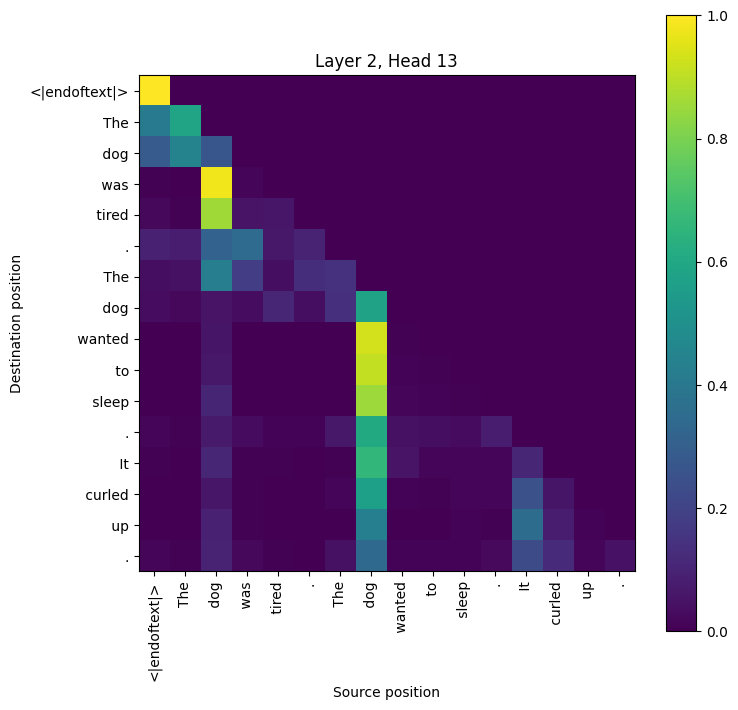

In [5]:
plot_attention(2, 13)